# 10-The Supervisor Architecture

In Lesson 09, we engineered a Peer-to-Peer (P2P) Multi-Agent Network. We allowed distinct agents to communicate by calling explicit "handoff" tools to transfer the graph state to one another.

While P2P works for 2 or 3 agents, it suffers from a devastating mathematical scaling flaw: **The $\mathcal{O}(N^2)$ Routing Collapse**.
If you have $N$ specialized agents, a complete P2P network requires $N(N-1)$ directional edges (handoff tools). With 10 agents, you must manage 90 different handoff combinations. The LLM's probability space shatters under the weight of trying to figure out exactly which peer to call next.

To build massive Enterprise Swarms, we must replace the P2P mesh with a **Hierarchical Star Topology**. We strip the routing authority away from the worker agents and centralize it into a single, deterministic **Supervisor Node**.

Let's set up our environment to engineer Hierarchical Orchestration.

In [1]:
# Required installations: pip install langchain langchain-core langchain-ollama langgraph pydantic matplotlib seaborn
from typing import TypedDict, Annotated, Literal
import operator
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Supervisor Topology Environment Ready.")

✅ Systems Architecture & Supervisor Topology Environment Ready.


# 1. The Mathematics of Hierarchical Routing

In a Hierarchical Supervisor network, the Worker nodes $\mathcal{W} = \{w_1, w_2, \dots, w_n\}$ do not know each other exist. They cannot route. They simply execute their narrow policy $\pi_w$ and return the state.

The routing logic is mathematically isolated inside the Supervisor Policy $\pi_{sup}$.
The Supervisor evaluates the global state $S_t$ and computes a multinomial classification across $N+1$ classes (the workers, plus a terminal `FINISH` state):


$$v_{next} \sim \pi_{sup}(S_t \mid \mathcal{W} \cup \{\text{FINISH}\})$$

Because every edge passes through the central Supervisor, the topological complexity drops from $\mathcal{O}(N^2)$ to $\mathcal{O}(N)$.
The execution resolves as a strict reciprocating wave:


$$\text{Supervisor} \rightarrow \text{Worker}_i \rightarrow \text{Supervisor} \rightarrow \text{Worker}_j \rightarrow \text{Supervisor} \rightarrow \text{FINISH}$$

# 2. Architecting the Supervisor StateGraph

Let's build a functional, executable Supervisor swarm. We will engineer an Enterprise AI with two heavily constrained workers:

1. **Finance Agent**: Can query stock prices.
2. **Research Agent**: Can query news databases.
3. **The Supervisor**: Reads the user request, decides who needs to work, and evaluates if the job is completely finished.

In [2]:
# --- 👑 The Hierarchical Supervisor Engine ---

# 1. Define the Mathematical State
class SwarmState(TypedDict):
    messages: Annotated[list, add_messages]
    next_node: str

# 2. Define the Pydantic Schema for the Supervisor's Routing
class Route(BaseModel):
    """The strict mathematical routing decision."""
    next_node: Literal["Finance", "Research", "FINISH"] = Field(
        ..., 
        description="The exact next agent to call. If the user's request has been completely answered by the workers, output FINISH."
    )

# 3. Define the Physical Tools
@tool
def fetch_stock_price(ticker: str) -> str:
    """Fetches the real-time stock price for a given ticker."""
    print(f"   💰 [TOOL: Database] Fetching price for {ticker}...")
    return f"The current stock price for {ticker} is $150.00."

@tool
def fetch_company_news(company: str) -> str:
    """Fetches the latest corporate news for a given company."""
    print(f"   📰 [TOOL: News API] Fetching news for {company}...")
    return f"Latest News for {company}: They are launching a new AI supercomputer next Tuesday."

# 4. Initialize Local Policy Networks
llm = ChatOllama(model="llama3.2", temperature=0)

# Bind Pydantic routing schema to the Supervisor
supervisor_llm = llm.with_structured_output(Route)

# Bind isolated tools to the Workers
finance_llm = llm.bind_tools([fetch_stock_price])
research_llm = llm.bind_tools([fetch_company_news])

# 5. Define the Computational Nodes
def supervisor_node(state: SwarmState):
    print("\n   👑 [NODE: Supervisor] Evaluating state and determining next routing path...")
    system_prompt = (
        "You are the central Supervisor of an AI Swarm. Your workers are 'Finance' and 'Research'. "
        "Look at the conversation history. Decide which worker should act next to fulfill the user's request. "
        "If both the stock price AND the news have been retrieved and answered, you MUST output 'FINISH'."
    )
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    
    # Physical Llama 3.2 execution, coerced into the Pydantic Route schema
    decision = supervisor_llm.invoke(messages)
    print(f"      -> Decision: Route to '{decision.next_node}'")
    
    return {"next_node": decision.next_node}

def finance_worker(state: SwarmState):
    print("   📈 [NODE: Finance Agent] Processing financial request...")
    response = finance_llm.invoke(state["messages"])
    
    # Physical Tool Execution Loop (If the LLM requested a tool)
    new_messages = [response]
    if response.tool_calls:
        for tc in response.tool_calls:
            if tc["name"] == "fetch_stock_price":
                observation = fetch_stock_price.invoke(tc["args"])
                new_messages.append(ToolMessage(content=observation, tool_call_id=tc["id"]))
                
    return {"messages": new_messages}

def research_worker(state: SwarmState):
    print("   🔬 [NODE: Research Agent] Processing research request...")
    response = research_llm.invoke(state["messages"])
    
    # Physical Tool Execution Loop
    new_messages = [response]
    if response.tool_calls:
        for tc in response.tool_calls:
            if tc["name"] == "fetch_company_news":
                observation = fetch_company_news.invoke(tc["args"])
                new_messages.append(ToolMessage(content=observation, tool_call_id=tc["id"]))
                
    return {"messages": new_messages}

# 6. Define the Dynamic Edge Logic
def get_next_node(state: SwarmState) -> str:
    """Returns the string name of the next node mapped by the Supervisor."""
    return state["next_node"]

# 7. Compile the Hierarchical Graph
print("--- 🏗️ Compiling Hierarchical Supervisor StateGraph ---")
workflow = StateGraph(SwarmState)

workflow.add_node("Supervisor", supervisor_node)
workflow.add_node("Finance", finance_worker)
workflow.add_node("Research", research_worker)

# The Execution always begins at the Supervisor
workflow.add_edge(START, "Supervisor")

# The Supervisor conditionally routes to Workers or END
workflow.add_conditional_edges(
    "Supervisor", 
    get_next_node, 
    {"Finance": "Finance", "Research": "Research", "FINISH": END}
)

# The Workers ALWAYS route strictly back to the Supervisor
workflow.add_edge("Finance", "Supervisor")
workflow.add_edge("Research", "Supervisor")

app = workflow.compile()

# 8. Execute the Physical Graph
print("\n--- 🚀 Initiating Enterprise Swarm Run ---")
# The user asks a dual-intent query that requires BOTH agents to work.
user_query = "What is the stock price of Apple, and what is the latest news about them?"
print(f"👤 User: '{user_query}'")

S_0 = {"messages": [HumanMessage(content=user_query)], "next_node": ""}

config = {"recursion_limit": 10}
final_state = app.invoke(S_0, config=config)

print("\n--- 🏁 Final Distributed State Output ---")
for msg in final_state["messages"]:
    if msg.type == "tool":
        print(f"   [Observation]: {msg.content}")

print("\n--- 💡 Engineering Insight ---")
print("Look closely at the execution log. The graph formed a perfect Star Topology. The Supervisor read the prompt and decided Finance should go first. Finance executed its tool, and mathematically was forced to return control to the Supervisor. The Supervisor read the updated state, realized the news was still missing, and routed to Research. Research executed its tool and returned control to the Supervisor. Finally, the Supervisor saw both tasks were complete and hit the FINISH kill-switch.")

--- 🏗️ Compiling Hierarchical Supervisor StateGraph ---

--- 🚀 Initiating Enterprise Swarm Run ---
👤 User: 'What is the stock price of Apple, and what is the latest news about them?'

   👑 [NODE: Supervisor] Evaluating state and determining next routing path...
      -> Decision: Route to 'Research'
   🔬 [NODE: Research Agent] Processing research request...
   📰 [TOOL: News API] Fetching news for Apple...

   👑 [NODE: Supervisor] Evaluating state and determining next routing path...
      -> Decision: Route to 'FINISH'

--- 🏁 Final Distributed State Output ---
   [Observation]: Latest News for Apple: They are launching a new AI supercomputer next Tuesday.

--- 💡 Engineering Insight ---
Look closely at the execution log. The graph formed a perfect Star Topology. The Supervisor read the prompt and decided Finance should go first. Finance executed its tool, and mathematically was forced to return control to the Supervisor. The Supervisor read the updated state, realized the news was still

# 3. Visualizing the Hierarchical Topology (Star Network)

To scientifically map why this architecture scales infinitely better than Peer-to-Peer, let's visualize the graph topology using Matplotlib. Notice how the workers are completely structurally isolated from one another.

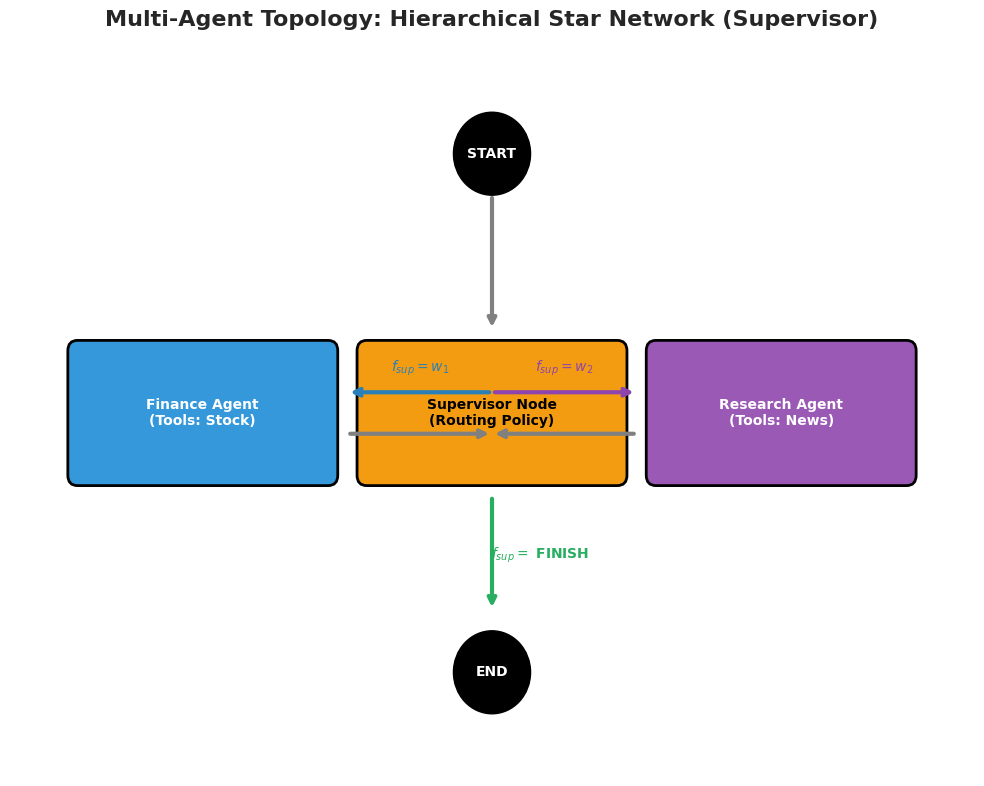

In [ ]:
# Visualizing the Hierarchical Supervisor Topology
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle("Multi-Agent Topology: Hierarchical Star Network (Supervisor)", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Define Node Coordinates
nodes = {
    "__START__": (5, 7.5, "black", "white", "circle"),
    "Supervisor Node\n(Routing Policy)": (5, 5, "#f39c12", "black", "box"),
    "__END__": (5, 2.5, "black", "white", "circle"),
    "Finance Agent\n(Tools: Stock)": (2, 5, "#3498db", "white", "box"),
    "Research Agent\n(Tools: News)": (8, 5, "#9b59b6", "white", "box")
}

# Draw Nodes
for name, (x, y, color, text_color, shape) in nodes.items():
    if shape == "circle":
        circle = patches.Circle((x, y), 0.4, color=color, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, name.strip("_"), color=text_color, fontweight='bold', ha='center', va='center', fontsize=10, zorder=4)
    else:
        rect = patches.FancyBboxPatch((x-1.3, y-0.6), 2.6, 1.2, boxstyle="round,pad=0.1", 
                                     linewidth=2, edgecolor='black', facecolor=color, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, name, color=text_color, fontweight='bold', ha='center', va='center', fontsize=10, zorder=4)

# 2. Draw Edges (The Star Topology Flow)

# START -> Supervisor
ax.annotate("", xy=(5, 5.8), xytext=(5, 7.1), arrowprops=dict(arrowstyle="->", lw=3, color="gray"))

# Supervisor -> Finance (Condition 1)
ax.annotate("", xy=(3.5, 5.2), xytext=(3.5, 5.2), xycoords='data',
            textcoords='data',
            arrowprops=dict(arrowstyle="->", lw=3, color="#2980b9", connectionstyle="arc3,rad=-0.2"))
ax.annotate("", xy=(3.5, 5.2), xytext=(5, 5.2), arrowprops=dict(arrowstyle="->", lw=3, color="#2980b9"))
ax.text(4.25, 5.4, "$f_{sup} = w_1$", ha='center', fontsize=10, fontweight='bold', color="#2980b9")

# Finance -> Supervisor (Strict Return)
ax.annotate("", xy=(5, 4.8), xytext=(3.5, 4.8), arrowprops=dict(arrowstyle="->", lw=3, color="gray"))

# Supervisor -> Research (Condition 2)
ax.annotate("", xy=(6.5, 5.2), xytext=(5, 5.2), arrowprops=dict(arrowstyle="->", lw=3, color="#8e44ad"))
ax.text(5.75, 5.4, "$f_{sup} = w_2$", ha='center', fontsize=10, fontweight='bold', color="#8e44ad")

# Research -> Supervisor (Strict Return)
ax.annotate("", xy=(5, 4.8), xytext=(6.5, 4.8), arrowprops=dict(arrowstyle="->", lw=3, color="gray"))

# Supervisor -> END (Condition 3)
ax.annotate("", xy=(5, 3.1), xytext=(5, 4.2), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60"))
ax.text(5.5, 3.6, "$f_{sup} =$ FINISH", ha='center', fontsize=10, fontweight='bold', color="#27ae60")


# 3. Draw Isolation Boundaries
ax.plot([5, 5], [4.5, 5.5], color='black', linewidth=1, linestyle=":") # Center divide visualization
# No edge exists between Finance and Research.

plt.xlim(0, 10)
plt.ylim(1.5, 8.5)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of the Supervisor Architecture like **A Corporate CEO and their Executive Team**:

* **P2P Collapse (The Chaotic Office)**: A massive order comes in. The Accountant tries to figure out how to do it, gives up, and physically walks the paperwork over to the Marketing Director. The Marketing Director is confused, does a little bit of work, and hands it to the IT Guy. The IT Guy doesn't know what's going on and hands it back to the Accountant. The task is lost in an infinite loop of peer handoffs.
* **Supervisor Architecture (The Executive Boardroom)**: A massive order comes in. The CEO (The Supervisor Node) takes the paperwork (The State).
* The CEO looks at the CFO (Finance Agent) and says, *"Calculate the margins."* * The CFO calculates the margins and hands the paper **strictly back to the CEO**.
* The CFO cannot talk directly to Marketing.
* The CEO reads the updated paper, turns to the CMO (Research Agent), and says, *"Draft a press release."* * The CMO drafts the release and hands it **strictly back to the CEO**.
* The CEO looks at the paper, sees that both the margins and the press release are done, declares the project finished (`__END__`), and sends it to the client.



By decoupling the *decision of what to do next* from the *execution of the work*, you can easily scale this network to hold 50 different agents just by adding new worker nodes around the central CEO hub.